# Machine Learning


## Supervised learning

Samples of input-output pairs (labelled outcomes)

**Classification** - predict the binary (or class) label for an unlabeled sample. Examples: logistic regression, SVM

**Regression** - predict a real-valued label for an unlabeled sample. Examples: linear regression 

<img width="400px" src="img/class_v_reg.png"/>

In classification models, the boundary separating the examples of different classes is called the *decision boundary*. For regression models, the line that best fits the data is the *regression line*. 

https://en.wikipedia.org/wiki/Supervised_learning

https://scikit-learn.org/stable/supervised_learning.html

*Decision trees and Random Forests we will implement herein are both considered supervised classification models. Therefore, this model type will be our main focus for this notebook.*

## Decision Trees

<img width="300px" src="img/decision_tree-example.jpeg" /> 

Decision trees can be used for both classification and regression.  They are similar to if/then statements.

* Tree depth: how many questions do we ask until we reach our decision? (denoted by its longest route)
* Root node: first decision
* Leaf node: final node of the tree

<img 
  width="500px"
  src="img/Decision-tree-showing-the-risk-of-malignant-effusion-when-medical-history-and-diagnostic.png" /> 

How is a decision tree trained? The goal is finding the best feature that maximizes the information gain at each node. 

Entropy: Quantifies the amount of uncertainty associated with a specific probability distribution. The higher the entropy, the less confident we are in the outcome.

Information Gain: How much do we gain (in terms of reduction in entropy) from knowing one of the features.

Advantages: 
* easy to interpret
* can use both qualitative and quantitative predictors and responses
* reproducible in clinical workflow
* fast and perform well on large datasets

Disadvantages:
* need an optimal choice at each node; at each step, the algorithm chooses the best result. Choosing the best result at a given step does not ensure an optimal decision when you make it to the leaf node
* prone to over-fitting, especially with deep trees (fix: can set a max depth--this limits variance, but at the expense of bias!)

Here are some links with more information about decision trees:
* https://www.datacamp.com/community/tutorials/decision-tree-classification-python
* http://dataaspirant.com/2017/02/01/decision-tree-algorithm-python-with-scikit-learn/
* https://towardsdatascience.com/how-to-visualize-a-decision-tree-from-a-random-forest-in-python-using-scikit-learn-38ad2d75f21c

## Bias-variance tradeoff

**Variance** is the error in the model due to sensitivity to the data. 

High variance means our model is *overfit* and has been trained to the noise in the data.

**Bias** is the error between the predicted and known labels for our data.

High bias means our model is *underfit* and does not predict the correct outcome for our data.

<img width="400px" src="img/hl_bias-hl_variance.png" /> 

We can think about (A) high variance and high bias, (B) low variance and high bias, (C) high variance and low bias, and (D) low variance and low bias. We are aiming to accomplish (D)!

So, when we look at the plot below we can relate variance and bias directly to how we are training our models. We are looking to hit that sweet spot where the bias and variance curves intersect. That is a good model.

<img width="400px" src="img/variance_v_bias.jpeg" /> 


In [1]:
import pandas as pds
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pydotplus
from sklearn.tree import DecisionTreeClassifier, export_graphviz # Import Decision Tree Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,\
        roc_auc_score, auc, precision_recall_curve, roc_curve
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import tree
from IPython.display import Image 

import random
## set seed for randomization
random.seed(42)

## Pima Indians Diabetes dataset
We will use the Pima Indians dataset to experiment with decision trees. The Pima are a group of Native Americans living in Arizona. A genetic predisposition allowed this group to survive normally to a diet poor of carbohydrates for years. In the recent years, because of a sudden shift from traditional agricultural crops to processed foods, together with a decline in physical activity, made them develop the highest prevalence of type 2 diabetes and for this reason they have been subject of many studies. 

The dataset can be downloaded here:

https://www.kaggle.com/uciml/pima-indians-diabetes-database#diabetes.csv

but I have already downloaded a local copy named `diabetes.csv`.

The dataset includes data from 768 women. The columns are defined as follows:

* `Pregnancies`: Number of times pregnant
* `Glucose`: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skin fold thickness (mm)
* `Insulin`: 2-Hour serum insulin (mu U/ml)
* `BMI`: Body mass index (weight in kg/(height in m)^2)
* `DiabetesPedigreeFunction`: The output of the pedigree function that provides measure of genetic influence and gives us an idea of the hereditary risk one might have with the onset of diabetes mellitus
* `Age`: Age (years)
* `Outcome`: Class variable (0 or 1) 268 of 768 are 1 (positive), the others are 0 (negative)

In [2]:
## load Pima Indians Diabetes dataset (downloaded May 14, 2019; N=768)
df = pds.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
## function to determine of a row has an missing value
def valid_value(row):
    if 0 == row['Glucose'] or \
       0 == row['BloodPressure'] or \
       0 == row['SkinThickness'] or \
       0 == row['Insulin'] or \
       0 == row['BMI'] or \
       0 == row['Age']:
        return False
    else:
        return True

## create dataframe with only valid rows
df_pima = df[df.apply(lambda row: valid_value(row), axis=1)]
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


## Implementing decision trees
Now that the data has been inspected and cleaned, we can implement a decisio tree.

For this will will use scikit-learn's `DecisionTreeClassifier()`:
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

To use this funcition, we need to define a dataset that contains the features used to build our decision tree, and a dataset that contains the target (or outcome) we are trying to coming to arrive at decision about.

By convention, scikit-learn often refers to the feature dataset as `X` and the target dataset as `y`.



In [5]:
#split dataset in features and target variable
feature_cols = \
    ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose',
     'BloodPressure','DiabetesPedigreeFunction', 'SkinThickness']

X = df_pima[feature_cols]
y = df_pima['Outcome']

In order to build the decision tree, we will need to split the dataset into a training set and a test set. The training set that is used to build the tree, and the test set that is used to evaluate it.

This is necessary for both the feature dataset (`X`) and the target/outcome dataset (`y`).

Scikit-learn's `train_test_split()` funciton allows us to easily do this.

In [6]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test


After creating the training and test datasets, we call the `DecisionTreeClassifier()` function  to build the decision tree. 

The hierarchical structure of a decision tree leads us to the final outcome by traversing through the nodes of the tree. Each node consists of an attribute or feature which is further split into more nodes as we move down the tree.

The Gini index (or Gini impurity) is the default method used determine the features to used at each node. Briefly, Gini index measures the degree or probability of a particular variable being wrongly classified when it is randomly chosen. If all the elements belong to a single class, then it can be called pure. The degree of Gini index varies between 0 and 1, where 0 denotes that all elements belong to a certain class or if there exists only one class, and 1 denotes that the elements are randomly distributed across various classes. A Gini Index of 0.5 denotes equally distributed elements into some classes.

*The goal is to have the lowest possible Gini index at each split.*

More information about the Gini index and other methods for feature splitting is found here:
* https://blog.quantinsti.com/gini-index/
* https://medium.com/deep-math-machine-learning-ai/chapter-4-decision-trees-algorithms-b93975f7a1f1

In the below code, I create a decision tree named `dtree`. After the tree is created, the `fit` method is called to train (i.e., build) the tree using the traing data `X_train`.

In [7]:
# create decision tree classifer object
dtree = DecisionTreeClassifier()

# train decision tree classifer
dtree = dtree.fit(X_train, y_train)

## Visualizing the tree
With the decision tree built, we can visualize the nodes. For this will use scikit-learn's `export_graphviz()` funciton:
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

The generated figure is difficult read, but if you **squint** you may be able to make out the features and values used to make the splits. Importantly, the Gini index of all leaf nodes is `0`.

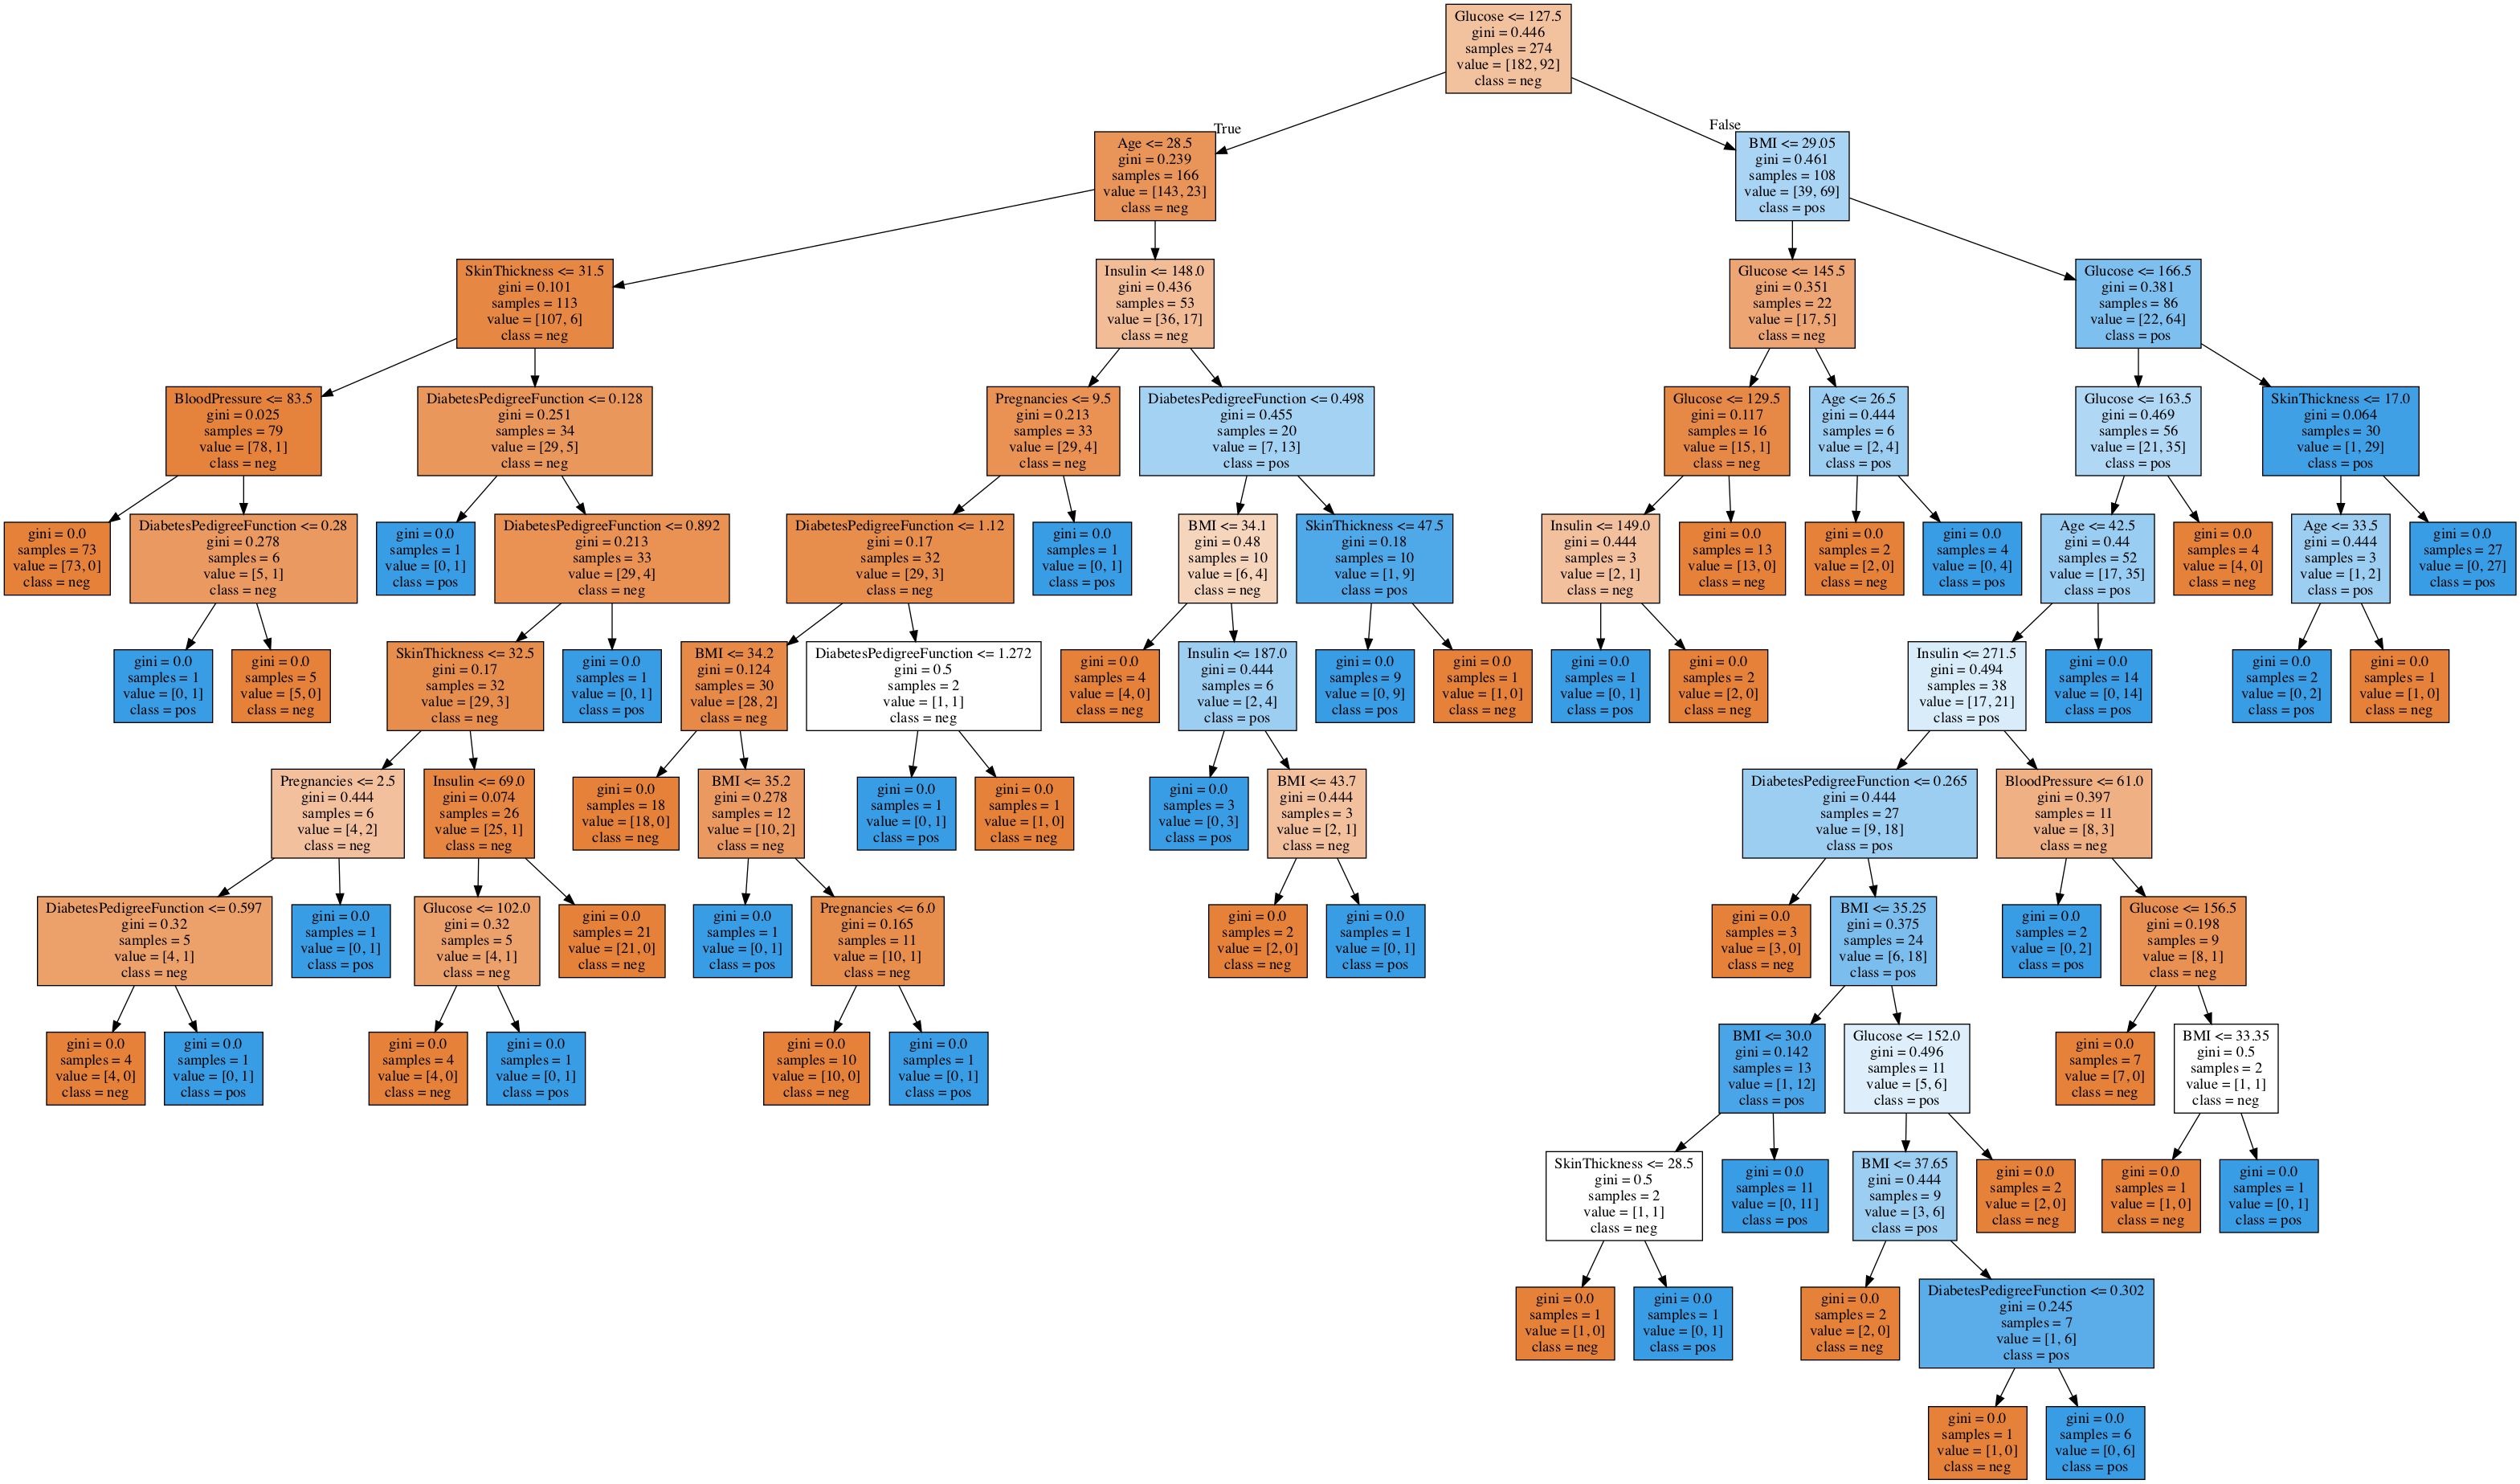

In [8]:
%matplotlib inline
from six import StringIO 
from IPython.display import Image, display

# export the tree as dot
dot_data = tree.export_graphviz(dtree, out_file=None, filled=True, 
                                feature_names=feature_cols, 
                                class_names=['neg','pos'])
# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)  

# Show graph
Image(graph.create_png())

## Tree pruning
A disadvantage of decision trees is that they are prone to overfitting as they grow larger and more complex. In order to avoid or correct overfitting we can **prune** the tree. One way to do this is by limiting the maximum depth of the tree. Another way is use cost complexity pruning. The former just limits the length of the longest path of the decision tree, which will stop the tree from becoming too complex and overfitting the data. Cost complexity pruning places a penalty on the number of terminal leaves that exist in the model, thus restricting the complexity of the tree. These pruning methods may increase training error, but the resulting model will be far more robust to your testing data.

<img width="500px" src="img/pruning.png" /> 

These *pruning* options are considered **hyperparameters**. Hyperparameters are parameters set prior to the model being trained and modulate how the model is trained and therefore directly influence the resulting parameters (weights) in the model.

Below I define a decision tree with a maximum depth of `4` and a decision tree with a cost complexity pruning value of `0.01`, and for convenience I use the labels `neg` and `pos` instead of `0` and `1`. 

It also makes the tree much easier to read :)

In [9]:
# prune the tree to a max depth of 4
dtree_shallow = DecisionTreeClassifier(max_depth=4)

# Train Decision Tree Classifer
dtree_shallow = dtree_shallow.fit(X_train,y_train)

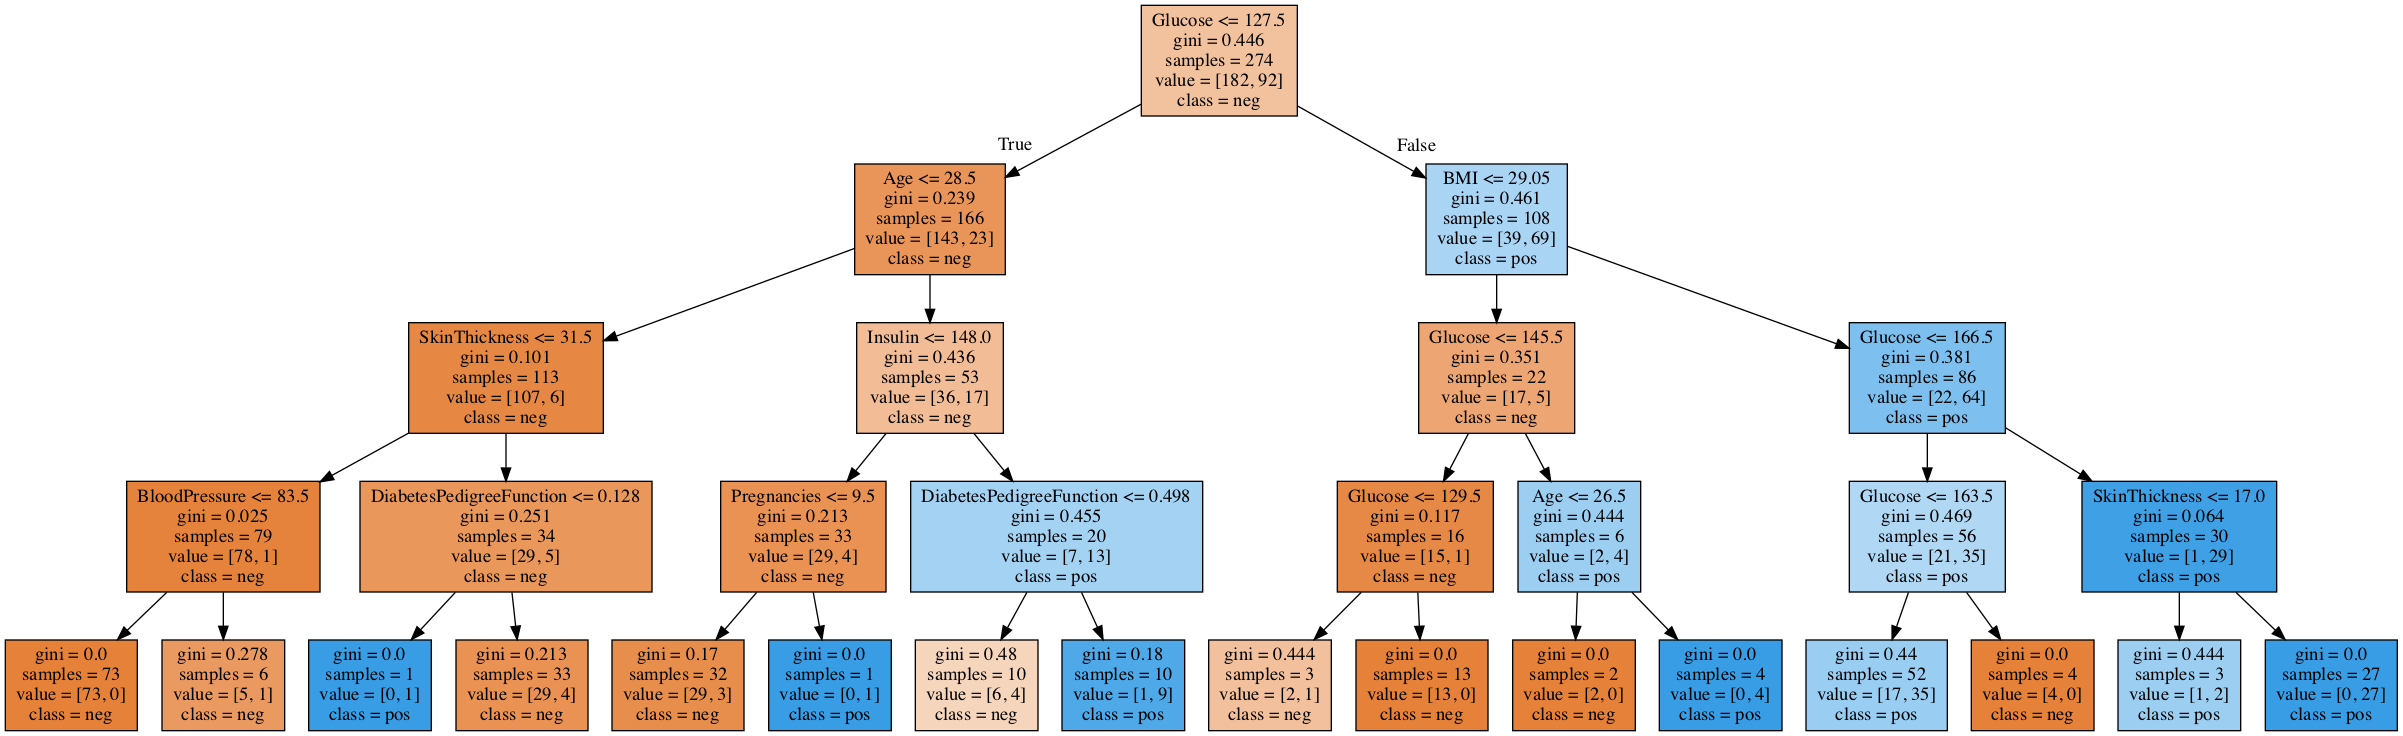

In [10]:
## visualize the pruned tree
dot_data = \
    tree.export_graphviz(dtree_shallow, out_file=None, filled=True, 
                         feature_names=feature_cols, 
                         class_names=['neg','pos'])

# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)  

# Show graph
Image(graph.create_png())

And now to run the "pruned" tree...

In [11]:
# prune the tree to using a complexity parameter of 0.01
dtree_pruned = DecisionTreeClassifier(ccp_alpha=0.01) # default criterion="gini"

# Train Decision Tree Classifer
dtree_pruned = dtree_pruned.fit(X_train,y_train)

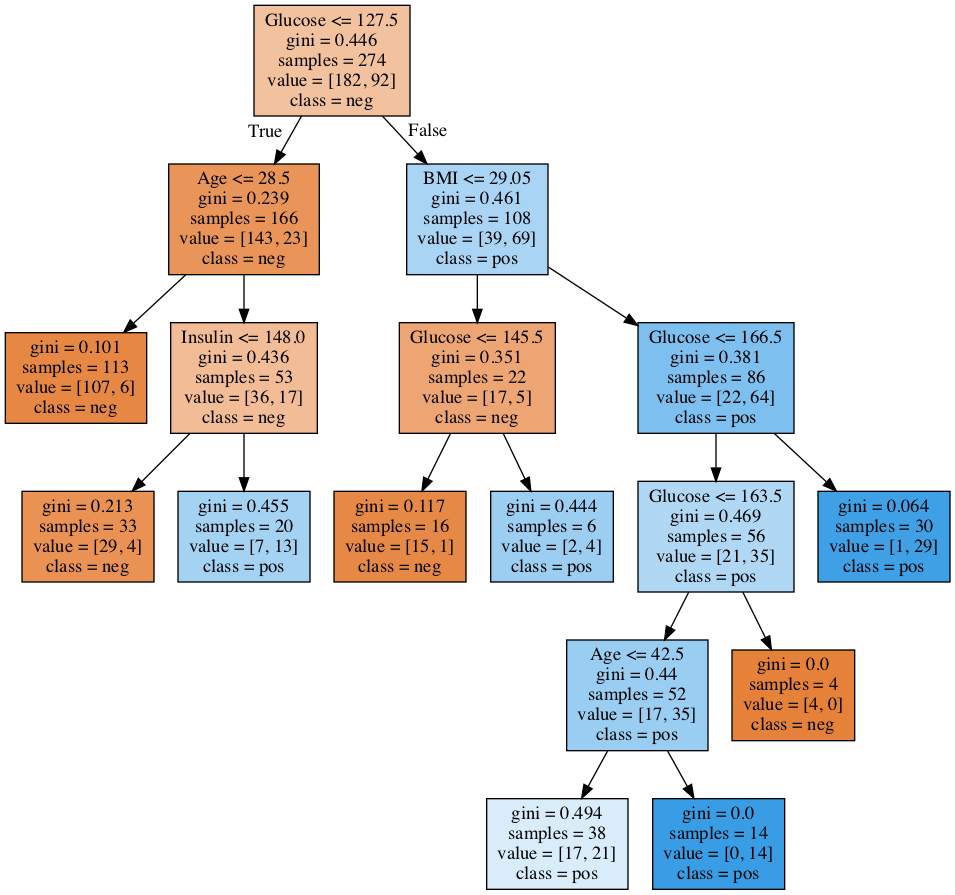

In [12]:
## visualize the pruned tree
dot_data = \
    tree.export_graphviz(dtree_pruned, out_file=None, filled=True, 
                         feature_names=feature_cols, 
                         class_names=['neg','pos'])

# Draw graph
graph = pydotplus.graph_from_dot_data(dot_data)  

# Show graph
Image(graph.create_png())

## Evaluating output
We need to now evaluate the decision trees (pruned and full). For this, we will use the decision tree `predict()` method. The output of this method will be stored in the variables `y_pred_tree`, `y_pred_shallow`, and `y_pred_pruned`. These (predicted) variables will assedd using a confusion matrix.

### Confusion matrix
<img width="400px" src="img/confusion_matrix3.png" />

A confusion matrix is a summary of prediction results on a classification problem.
The number of correct and incorrect predictions are summarized with count values and broken down by each class. This is the key to the confusion matrix.
The confusion matrix shows the ways in which your classification model is confused when it makes predictions.
It gives us insight not only into the errors being made by a classifier but more importantly the types of errors that are being made. (https://www.geeksforgeeks.org/confusion-matrix-machine-learning/)

**Definition of the Terms**:
* Positive (P) : Observation is positive (for example: is an apple).
* Negative (N) : Observation is not positive (for example: is not an apple).
* True Positive (TP) : Observation is positive, and is predicted to be positive.
* False Negative (FN) : Observation is positive, but is predicted negative.
* True Negative (TN) : Observation is negative, and is predicted to be negative.
* False Positive (FP) : Observation is negative, but is predicted positive.

Using the confusion matrix, we can define the following metrics of evaluation.

**Accuracy:**
* (TP + TN) / (TP + TN + FP + FN)
* Accuracy is the ratio of correct predictions to total predictions made. However, there are problems with accuracy. It assumes equal costs for both kinds of errors. A 99% accuracy can be excellent, good, mediocre, poor or terrible depending upon the problem.


**Recall:**
* TP / (TP + FN)
* Recall is the ability of a classifier to find all positive instances. High recall indicates a small number of false negatives.


**Precision:**
* TP / (TP + FP)
* Precision is the ability of a classifier not to label an instance positive that is actually negative. High precision indicates a small number of false positives.

**F1 score (F measure):**
* (2 * Recall * Precision) / (Recall + Precision)
* Since we have two measures (Precision and Recall) it helps to have a measurement that represents both of them. We calculate an F1 score that uses Harmonic Mean in place of Arithmetic Mean as it punishes the extreme values more. 

And now to run the "shallow" tree...

In [13]:
## Predict the response for dtree, dtree_shallow, and dtree_pruned decision trees
y_pred_tree = dtree.predict(X_test)
y_pred_shallow = dtree_shallow.predict(X_test)
y_pred_pruned = dtree_pruned.predict(X_test)

Sci-kit learn also provides `accuracy_score`, `recall_score`, and `f1_score` functions to make these calculations easier.

In [14]:
print("tree:", accuracy_score(y_test, y_pred_tree))
print("shallow:", accuracy_score(y_test, y_pred_shallow))
print("pruned:", accuracy_score(y_test, y_pred_pruned))

tree: 0.6864406779661016
shallow: 0.7372881355932204
pruned: 0.7627118644067796


Here are the recall and precision scores.

In [15]:
print("tree:", recall_score(y_test, y_pred_tree))
print("shallow:", recall_score(y_test, y_pred_shallow))
print("pruned:", recall_score(y_test, y_pred_pruned))

tree: 0.631578947368421
shallow: 0.6842105263157895
pruned: 0.7105263157894737


In [16]:
print("tree:", precision_score(y_test, y_pred_tree))
print("shallow:", precision_score(y_test, y_pred_shallow))
print("pruned:", precision_score(y_test, y_pred_pruned))

tree: 0.5106382978723404
shallow: 0.5777777777777777
pruned: 0.6136363636363636


In [18]:
print("tree:", f1_score(y_test, y_pred_tree))
print("shallow:", f1_score(y_test, y_pred_shallow))
print("pruned:", f1_score(y_test, y_pred_pruned))

tree: 0.5647058823529411
shallow: 0.6265060240963854
pruned: 0.6585365853658537


Notice that the accuracy and precision scores in the pruned and full trees are close. However the recall score is better in the pruned tree, meaning that the pruned tree has a smaller number of false negatives. Compare the lower left boxes in the two confusion matrices below.

If we wish, we can also visualize the confusion matrix of the trees. For convenience, I will define a function to do this. This will allow us to more easily visualize the confusion matrix later.

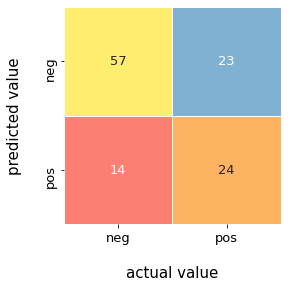

In [17]:
def show_confusion_matrix(y_test, y_pred, palette="Set3"):
    ## see: https://www.geeksforgeeks.org/confusion-matrix-machine-learning/
    ##      https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html
    ##      https://classeval.wordpress.com/introduction/basic-evaluation-measures/
    matrix = confusion_matrix(y_test, y_pred)

    colors = sns.color_palette(palette) # set the colors to use for heatmap
    # print(colors.as_hex()) # uncomment this to see color palette

    ax = sns.heatmap(matrix, square=True, annot=True, fmt='d', 
                     cbar=False, cmap=colors, vmin=-1, annot_kws={"size":13}, linewidths=1.0)

    # set labels on figure
    ax.set_xticklabels(labels=["neg","pos"], fontsize=13)
    ax.set_yticklabels(labels=["neg","pos"], fontsize= 13)
    plt.xlabel("\nactual value", fontsize=15)
    plt.ylabel("predicted value\n", fontsize=15)
    plt.show()

## show confusion matrix for dtree
show_confusion_matrix(y_test, y_pred_tree)

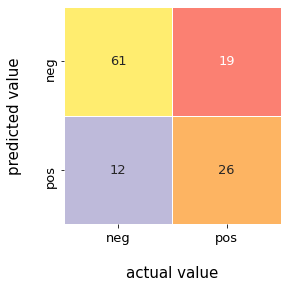

In [19]:
## show confusion matrix for dtree_pruned
show_confusion_matrix(y_test, y_pred_shallow)

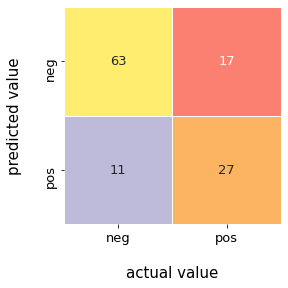

In [20]:
## show confusion matrix for dtree_pruned
show_confusion_matrix(y_test, y_pred_pruned)

As an exercise, use one of the above confusion matrices to compute the recall and precision of either the full or pruned decision tree.
* Recall: TP / (TP + FN)
* Precision: TP / (TP + FP)

## Random forest
Random forest classifers are similar to decision trees in that they use hierarchical structures to split the dataset based on features. However, unlike decision trees, these classifiers use muliple decision trees (a "forest") in classification process using a method called *bagging*. Random forest is called an *ensemble* method because we have multiple classifiers by which we make our final prediction.

The random forest algorithm consists of four general steps:
* Select random samples from a given dataset - *bootstrapping*.
* Construct a decision tree for each sample and get a prediction result from each decision tree.
* Perform a vote for each predicted result.
* Select the prediction result with the most votes as the final prediction - *aggregating*.

<img width="500px" src="img/random_forest_voting.png" />

**Advantages**
* Random forests is considered as a highly accurate and robust method because of the number of decision trees participating in the process.
* It does not suffer from the overfitting problem. The main reason is that it takes the average of all the predictions, which cancels out the biases.
* The algorithm can be used in both classification and regression problems.
* Random forests can also handle missing values. There are two ways to handle these: using median values to replace continuous variables, and computing the proximity-weighted average of missing values.
* You can get the relative feature importance, which helps in selecting the most contributing features for the classifier.

**Disadvantages**
* Random forests is slow in generating predictions because it has multiple decision trees. Whenever it makes a prediction, all the trees in the forest have to make a prediction for the same given input and then perform voting on it. This whole process is time-consuming.
* The model is difficult to interpret compared to a decision tree, where you can easily make a decision by following the path in the tree.



## Implementing random forest
Like decision trees, building and fitting a random forest classifier is a straightforward task  in scikit-learn. First, we define a random forest classifier variable, and, second, we train the classifier by calling the `fit` method.

Random forest has many hyperparameters. Hyperparameters included in Random Forest are:
* `n_estimators` = number of trees in the forest
* `criterion` = the criterion used to choose a split at each node (e.g. gini, entropy, mse, etc.)
* `max_depth` = maximum length of the longest route in each tree
* `min_samples_split` = minimum number of samples to split on at a node
* `max_leaf_nodes` = maximum number of leaf nodes
* `max_features` = maximum number of random features to test at each node
* `max_samples` = size of bootstrapped dataset for each tree

In [21]:
## build and fit random forest classifier
rfc = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, random_state=42)

## Evaluating random forest
We can evaluate the our random forest classifier by calculating the accuracy, recall, precision, and F1 scores.

In [22]:
y_pred_forest = rfc.predict(X_test)
y_proba_forest = list(zip(*rfc.predict_proba(X_test)))[1]
accuracy_score(y_test, y_pred_forest)

0.7457627118644068

In [23]:
recall_score(y_test, y_pred_forest)

0.47368421052631576

In [24]:
precision_score(y_test, y_pred_forest)

0.6428571428571429

In [25]:
f1_score(y_test, y_pred_forest)

0.5454545454545454

As before, we can display the `confusion_matrix` of our classifier.

In [26]:
## get values for confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_forest).ravel()
print((tn, fp, fn, tp))

(70, 10, 20, 18)


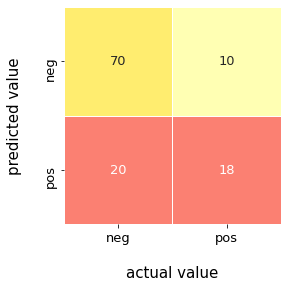

In [27]:
## show confusion matrix for random forest
show_confusion_matrix(y_test, y_pred_forest)

In [28]:
def plot_static_roc_curve(fpr, tpr):
    plt.figure(figsize=[5,5])
    plt.fill_between(fpr, tpr, alpha=.5, color='darkorange')
    # Add dashed line with a slope of 1
    plt.plot(fpr, tpr, color='darkorange', lw=2)
    plt.plot([0,1], [0,1], linestyle=(0, (5, 5)), linewidth=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve");
    
def plot_static_pr_curve(recall, precision):
    plt.figure(figsize=[5,5])
    plt.fill_between(recall, precision, alpha=.5, color='darkorange')
    plt.plot(recall, precision, color='darkorange', lw=2)
    # Add dashed line with a slope of 1
    plt.plot([1,0], [0,1], linestyle=(0, (5, 5)), linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve");

In [29]:
roc_auc_score(y_test, y_proba_forest)

0.8006578947368421

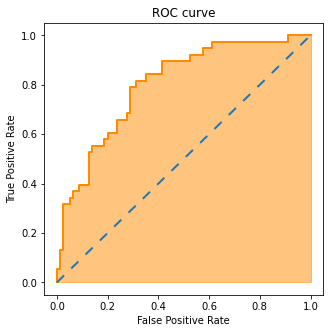

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_forest)
plot_static_roc_curve(fpr,tpr)

In [31]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_forest)
auc(recall, precision)

0.6487388859165529

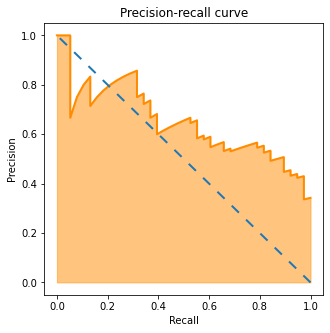

In [32]:
plot_static_pr_curve(recall,precision)

## Hyperparameter tuning

Cross-validation is key to choosing the best possible hyperparameters. This involves splitting the training set into $k$ number of subsets where one subset is used as a validation set and the remaining $k-1$ are used for training. This is then completed over all possible sets of $k$ and the average of the metrics is used to assess the model with the given hyperparameters.

To further this idea, we can use cross-validation in concert with a *grid search* which runs a model with variable hyperparameters that are defined by lists of values. This will "check" the metrics for each of this runs and average them. The optimal combination of hyperparameters will be outputted as the best model.

In [33]:
# Number of trees to be used
rfc_n_estimators = [int(x) for x in np.linspace(100, 500, 5)]
# Maximum length in tree
rfc_max_depth = [int(x) for x in np.linspace(2, 10, 5)]

rfc_grid = {'n_estimators': rfc_n_estimators,
            'max_depth': rfc_max_depth}

# Create the model to be tuned
rfc_base = RandomForestClassifier(random_state=42)

# Create the random search Random Forest
rfc_random = RandomizedSearchCV(estimator = rfc_base, param_distributions = rfc_grid, 
                                n_iter = 200, cv = 4, scoring='f1',
                                random_state = 42, n_jobs = -1)

# Fit the random search model
rfc_random.fit(X_train, y_train)

/Users/ludo/src/anaconda3/envs/bmi-bootcamp/lib/python3.9/site-packages/sklearn/model_selection/_search.py:285: UserWarning: The total space of parameters 25 is smaller than n_iter=200. Running 25 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'max_depth': [2, 4, 6, 8, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='f1')

In [34]:
# Get the optimal parameters
rfc_random.best_params_

{'n_estimators': 400, 'max_depth': 6}

In [35]:
y_pred_best = rfc_random.predict(X_test)
accuracy_score(y_test, y_pred_best)

0.7372881355932204

In [36]:
f1_score(y_test, y_pred_best)

0.5507246376811595

## Feature ranking
In addition to evaluating the random forest classifier, it is sometimes helpful to see how important each of the features were in arriving at final predictions. If we notice that a feature is of little importance, we can eliminate it from our training dataset in order to gain efficiency.

When building a random forest classifier, scikit-learn returns a variable named `feature_importances_`.

In [37]:
## find important features
rfc.feature_importances_

array([0.08414302, 0.17423142, 0.10691552, 0.14351671, 0.3257111 ,
       0.04085355, 0.06197045, 0.06265825])

The raw output is a little difficult to interpret. So, we will put the output in a Pandas Series.

In [38]:
feature_imp = \
    pds.Series(rfc.feature_importances_, index=feature_cols).sort_values(ascending=False)
feature_imp

Glucose                     0.325711
Insulin                     0.174231
Age                         0.143517
BMI                         0.106916
Pregnancies                 0.084143
SkinThickness               0.062658
DiabetesPedigreeFunction    0.061970
BloodPressure               0.040854
dtype: float64

We can also visualize the feature importances using a seaborn barplot.

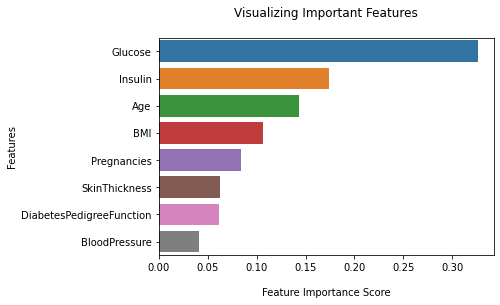

In [39]:
## visualize important features
%matplotlib inline

# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)

# Add labels to your graph
plt.xlabel('\nFeature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features\n")

plt.show()

## XGBoost

How does this differ from Random Forest? Random Forest uses bagging in order to train a final model. XGBoost works by a method called **boosting**, which is an iterative, sequential method that adds a new decision tree to the overall model at each step to minimize error from the previous trees. Each new tree is a *weak learner* that when all combined creates a strong learner that will accurately predict the outcome.

<img width="500px" src="img/xgboost_boosting.png" />

A problem with XGBoost is that it is highly sensitive to it's hyperparameters. If too many trees are added, it can be overfit. Moreover, the `learning rate` is crucial because the model will perform better if trained slowly, but the likelihood of many trees being created increases with a decreaed learning rate. FInding the right balance for the model is key to the robustness and generalizability of the model.


In [40]:
import xgboost as xgb

In [41]:
## build and fit XGBoost classifier
xgc = xgb.XGBClassifier(objective='reg:logistic',n_estimators=100, \
                        alpha=0.01, max_depth=4, learning_rate=0.1, \
                        colsample_bytree=0.3, use_label_encoder=False)
xgc.fit(X_train, y_train)

y_pred_boost = xgc.predict(X_test)

/Users/ludo/src/anaconda3/envs/bmi-bootcamp/lib/python3.9/site-packages/xgboost/data.py:112: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  warnings.warn(


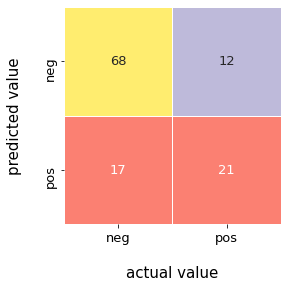

In [42]:
show_confusion_matrix(y_test, y_pred_boost)

In [43]:
accuracy_score(y_test, y_pred_boost)

0.7542372881355932

In [44]:
recall_score(y_test, y_pred_boost)

0.5526315789473685

In [45]:
precision_score(y_test, y_pred_boost)

0.6363636363636364

In [46]:
f1_score(y_test, y_pred_boost)

0.5915492957746479

###### feature_imp = \
    pds.Series(xgc.feature_importances_, index=feature_cols).sort_values(ascending=False)

%matplotlib inline

# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)

# Add labels to your graph
plt.xlabel('\nFeature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features\n")

plt.show()

## Wrapping up
In this module, we have covered a numbered of important concepts related to decision tree and random forest classifiers, such as:
* Inspecting the data using correlation matrices and histograms
* Building training and test datasets
* Defining decision tree and random forest classifiers using scikit-learn and predicting target classes
* Evaluating classifiers using a confusion matrix and calculating the accuracy, precision, recall, and F1 scores.
* Inspecting the importance of features in our classifier